Generating dataset...
Training model...
Epoch 5/30, Loss: 0.3133
Epoch 10/30, Loss: 0.1161
Epoch 15/30, Loss: 0.0639
Epoch 20/30, Loss: 0.0441
Epoch 25/30, Loss: 0.0357
Epoch 30/30, Loss: 0.0254
Dataset saved: reasoning_output.csv


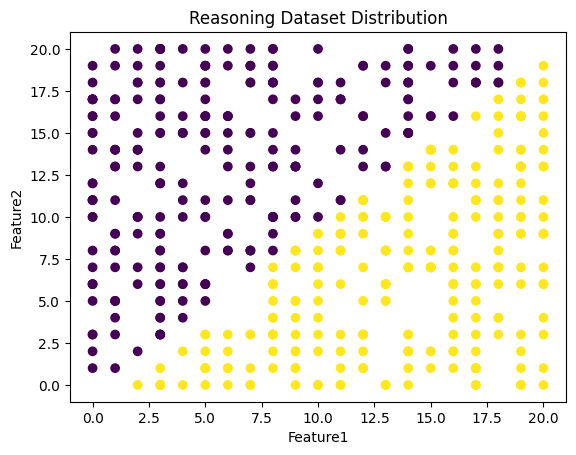

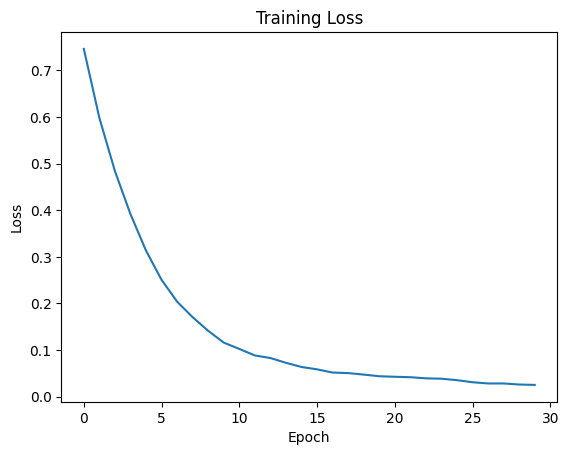

In [1]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# =========================
# CONFIG
# =========================
NUM_SAMPLES = 500
NUM_EPOCHS = 30
INPUT_FILE = "reasoning_data.csv"
OUTPUT_FILE = "reasoning_output.csv"

# =========================
# DATASET GENERATOR (REASONING)
# =========================
def generate_data(n):
    data = []

    for _ in range(n):
        a = random.randint(0, 20)
        b = random.randint(0, 20)

        # Label = reasoning rule (not just random)
        label = 1 if (a * 2 + 3) > (b * 2 + 3) else 0

        data.append({
            "feature1": a,
            "feature2": b,
            "label": label
        })

    df = pd.DataFrame(data)
    df.to_csv(INPUT_FILE, index=False)
    return df


# =========================
# DATASET CLASS
# =========================
class ReasoningDataset(Dataset):
    def __init__(self, csv_file):
        df = pd.read_csv(csv_file)
        self.X = df[["feature1", "feature2"]].values.astype(np.float32)
        self.y = df["label"].values.astype(np.float32).reshape(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx]), torch.tensor(self.y[idx])


# =========================
# MODEL (FIXED)
# =========================
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(2, 16)
        self.fc2 = nn.Linear(16, 16)
        self.fc3 = nn.Linear(16, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))
        return x


# =========================
# TRAIN FUNCTION
# =========================
def train_model(model, dataloader, criterion, optimizer):
    model.train()
    total_loss = 0

    for X_batch, y_batch in dataloader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


# =========================
# MAIN
# =========================
def main():
    print("Generating dataset...")
    df = generate_data(NUM_SAMPLES)

    dataset = ReasoningDataset(INPUT_FILE)
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

    model = Net()
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    losses = []

    print("Training model...")
    for epoch in range(NUM_EPOCHS):
        loss = train_model(model, dataloader, criterion, optimizer)
        losses.append(loss)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Loss: {loss:.4f}")

    # =========================
    # SAVE OUTPUT
    # =========================
    df.to_csv(OUTPUT_FILE, index=False)
    print("Dataset saved:", OUTPUT_FILE)

    # =========================
    # VISUALIZATION
    # =========================
    plt.figure()
    plt.scatter(df["feature1"], df["feature2"], c=df["label"])
    plt.xlabel("Feature1")
    plt.ylabel("Feature2")
    plt.title("Reasoning Dataset Distribution")
    plt.show()

    plt.figure()
    plt.plot(losses)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.show()


if __name__ == "__main__":
    main()